In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv('/content/train.csv')

In [3]:
#first 5 rows
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
#data shape
df.shape

(1460, 81)

In [6]:
#data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
#check missing values
df.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [8]:
#select features and target
features = ['GrLivArea', 'BedroomAbvGr', 'FullBath']

target = 'SalePrice'

X = df[features]

y = df[target]

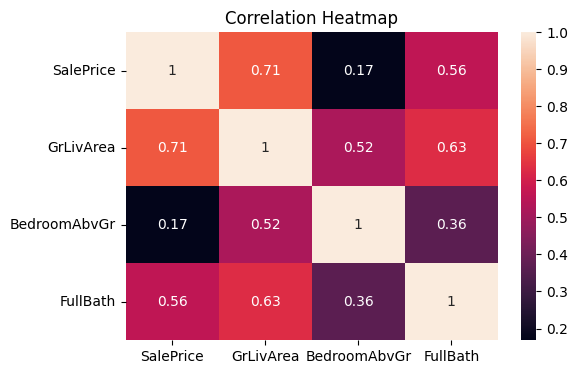

In [9]:
#correlation heatmap
plt.figure(figsize=(6,4))

sns.heatmap(df[['SalePrice','GrLivArea','BedroomAbvGr','FullBath']].corr(),
            annot=True)

plt.title("Correlation Heatmap")

plt.show()

In [10]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
#train linear regression model
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [14]:
#display model coeffients
for feature, coef in zip(features, model.coef_):
    print(feature, ":", coef)

GrLivArea : 104.0263070122644
BedroomAbvGr : -26655.16535734126
FullBath : 30014.324108956596


In [16]:
#Make predictions
y_pred = model.predict(X_test)

In [17]:
#calculate MAE
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 35788.061292436294


In [18]:
#calculate RMSE
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 52975.71771338122


In [20]:
#calculate R^2 Score
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6341189942328371


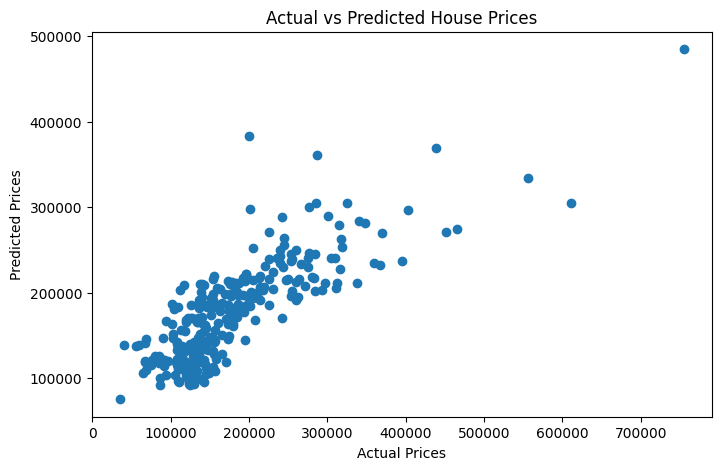

In [21]:
#actual vs predicted gragh
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Prices")

plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [22]:
#predict new house price
new_house = [[2000, 3, 2]]

predicted_price = model.predict(new_house)

print("Predicted House Price:", predicted_price[0])

Predicted House Price: 240377.51479736282


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


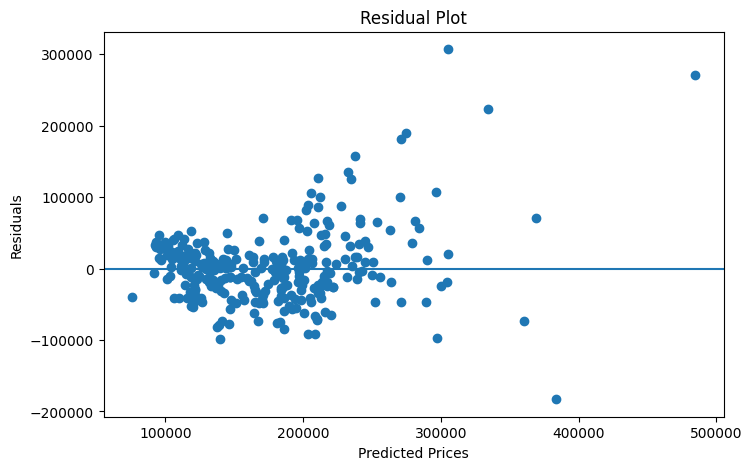

In [23]:
#residual plot
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Prices")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()